# Explicabilidad — SHAP sobre el clasificador (Fase 3)

Electivo de **explicabilidad**. Descompone las predicciones del modelo en aportes
por feature (TreeSHAP), conectando con interpretabilidad/transparencia de modelos.

**Invariantes del proyecto:** este notebook **solo consume desde `src/`** — toda la
lógica de SHAP vive en `src.models.explain` y la importan tanto la API como este
notebook (única fuente, invariante 3). No se reentrena ni re-fitea nada: se carga el
bundle exportado.

**Decisión de diseño:** el input es `[tabular ⊕ embedding ResNet de 512 dims]`. Las
512 dimensiones del embedding no son interpretables una a una, así que se agregan en un
único bucket `visual_embedding`; las features tabulares se reportan con su nombre. El
cálculo usa el **TreeSHAP nativo de XGBoost** (`pred_contribs`), no la librería `shap`,
para que la API explique sin dependencias pesadas.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap  # solo para el summary plot; el cálculo de valores es nativo de XGBoost

# Ubicar la raíz del repo y exponer `import src`.
here = Path.cwd()
root = next(p for p in [here, *here.parents] if (p / 'configs' / 'dataset.yaml').is_file())
sys.path.insert(0, str(root / 'backend'))

from src.data.config import DatasetConfig
from src.data.dataset import load_dataset
from src.models.config import TrainConfig
from src.models.export import load_bundle, predict_frame
from src.models.train import split_dataset
from src.models.explain import VISUAL_FEATURE, grouped_contributions

# Cargar el bundle servido (modelo + preprocesador fiteado) y el dataset.
train_cfg = TrainConfig.from_yaml(root / 'configs' / 'train.yaml')
dataset_cfg = DatasetConfig.from_yaml(root / 'configs' / 'dataset.yaml')
bundle = load_bundle(train_cfg.paths.resolved('model_dir'))
manifest, features = load_dataset(dataset_cfg)
classes = sorted(manifest['label'].unique().tolist())
splits = split_dataset(manifest, features, classes)
test = splits['test']
test_labels = manifest['label'].to_numpy()[manifest['split'].to_numpy() == 'test']
print('modelo:', bundle.model_type, bundle.model_version)
print('clases:', bundle.classes)
print('ventanas de test:', len(test.tabular))

modelo: xgboost v1-tuned-xgboost-91c40640
clases: ['background', 'card', 'corner', 'goal', 'substitution']
ventanas de test: 72


## 1. Importancia global de features

Para cada ventana de test calculamos los aportes SHAP **para su clase predicha** y
agregamos. El gráfico de barras muestra la magnitud media |SHAP| por bucket: cuánto
pesa cada feature en las decisiones del modelo. Como el modelo tuneado pasó por feature
selection (Fase 3.1), solo aparecen las features que efectivamente usa.


magnitud media |SHAP| por feature:
team_is_home             2.0999
visual_embedding         0.3362
visible                  0.3229
secs_since_last_event    0.2655
half                     0.0009
league                   0.0000


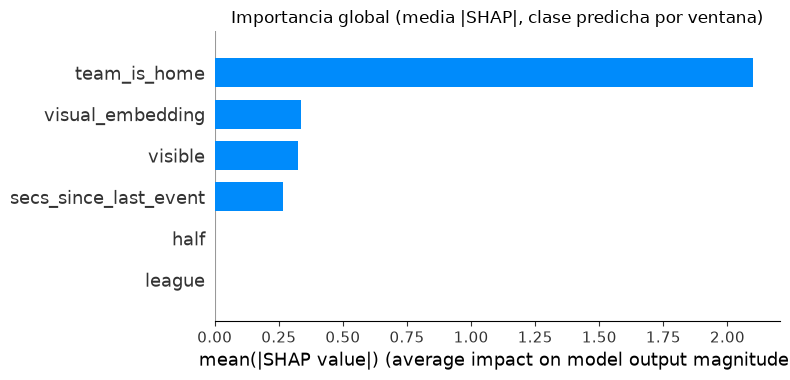

In [2]:
contribs = grouped_contributions(bundle, test.tabular, test.embedding)
shap_df = pd.DataFrame(contribs).fillna(0.0)
importance = shap_df.abs().mean().sort_values(ascending=False)
print('magnitud media |SHAP| por feature:')
print(importance.round(4).to_string())

shap.summary_plot(shap_df.values, feature_names=list(shap_df.columns), plot_type='bar', show=False)
plt.title('Importancia global (media |SHAP|, clase predicha por ventana)')
plt.tight_layout()
plt.show()

## 2. Señal visual vs. contexto tabular

¿Cuánto de la explicación viene del frame (embedding ResNet) y cuánto del contexto
tabular point-in-time? Sumamos la masa |SHAP| de cada lado sobre todo el test.


masa visual:     24.20  ( 11.1%)
masa tabular:   193.62  ( 88.9%)


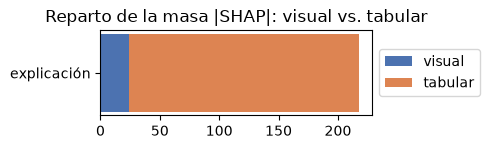

In [3]:
visual_mass = float(shap_df[VISUAL_FEATURE].abs().sum()) if VISUAL_FEATURE in shap_df else 0.0
tabular_mass = float(shap_df.drop(columns=[VISUAL_FEATURE], errors='ignore').abs().sum().sum())
total = visual_mass + tabular_mass
print(f'masa visual:  {visual_mass:8.2f}  ({100*visual_mass/total:5.1f}%)')
print(f'masa tabular: {tabular_mass:8.2f}  ({100*tabular_mass/total:5.1f}%)')

plt.figure(figsize=(5, 1.6))
plt.barh(['explicación'], [visual_mass], label='visual', color='#4c72b0')
plt.barh(['explicación'], [tabular_mass], left=[visual_mass], label='tabular', color='#dd8452')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title('Reparto de la masa |SHAP|: visual vs. tabular')
plt.tight_layout()
plt.show()

## 3. Casos individuales (desglose por predicción)

Para ventanas concretas de distintas clases mostramos el desglose de aportes hacia la
clase predicha. Verde = empuja hacia la clase; rojo = en contra. Es exactamente la
explicación que la API devuelve en el campo `explanations` de `/predict`.


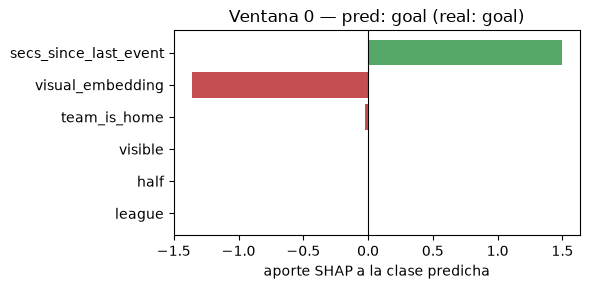

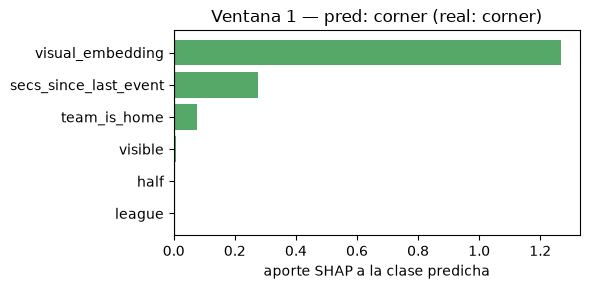

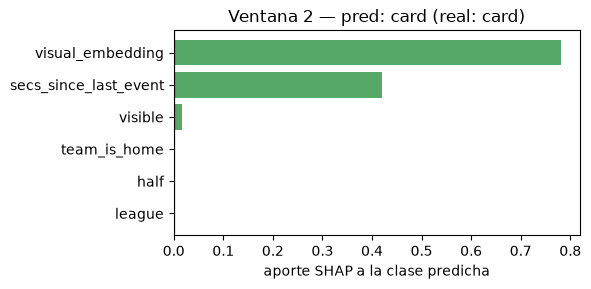

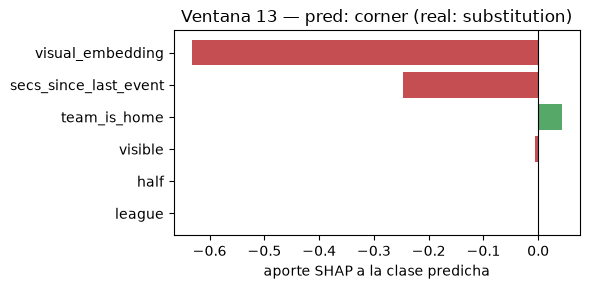

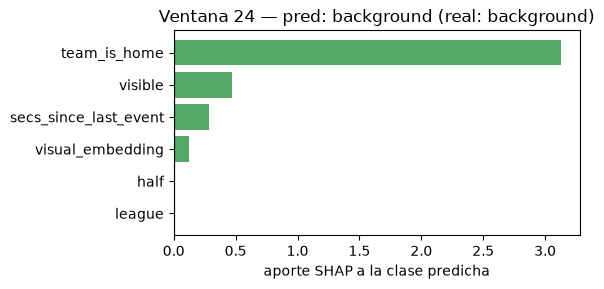

In [4]:
def explain_case(i: int) -> None:
    row_tab = test.tabular.iloc[[i]]
    row_emb = test.embedding[[i]]
    g = grouped_contributions(bundle, row_tab, row_emb)[0]
    items = sorted(g.items(), key=lambda kv: abs(kv[1]))
    names = [k for k, _ in items]
    vals = [v for _, v in items]
    colors = ['#55a868' if v >= 0 else '#c44e52' for v in vals]
    pred, _ = predict_frame(bundle, row_tab, row_emb)
    plt.figure(figsize=(6, 3))
    plt.barh(names, vals, color=colors)
    plt.axvline(0, color='k', lw=0.8)
    plt.title(f'Ventana {i} — pred: {pred[0]} (real: {test_labels[i]})')
    plt.xlabel('aporte SHAP a la clase predicha')
    plt.tight_layout()
    plt.show()

# Una ventana por cada clase presente en test (primera aparición).
seen: set[str] = set()
for i, lbl in enumerate(test_labels):
    if lbl not in seen:
        seen.add(lbl)
        explain_case(i)

## 4. Conclusiones

- SHAP descompone cada predicción en aportes legibles: el bucket `visual_embedding`
  (señal del frame) y las features tabulares point-in-time con su nombre.
- El reparto visual/tabular cuantifica de dónde saca la información el modelo.
- Solo aparecen las features que el modelo tuneado conserva tras la feature selection
  (Fase 3.1): explicabilidad y optimización quedan consistentes.
- La **misma** lógica (`src.models.explain`) alimenta la API (`/predict` → `explanations`)
  y este notebook — sin duplicar, evitando training-serving skew también en la explicación.
